# AI Agents: Overview, Frameworks, and Design Patterns

A comprehensive session covering:
1. **What is an Agent?** — definition, anatomy, and how they differ from plain LLM calls
2. **Agent Framework Overview** — the landscape of tools and libraries
3. **Workflow & Agent Design Patterns** — Anthropic's recommended patterns, each with a Gradio UI
4. **Model Context Protocol (MCP)** — what it is, building a server, wiring an OpenAI agent to it

## Setup

In [16]:
import os
import json
import time
import concurrent.futures
from collections import Counter
from dotenv import load_dotenv
from openai import OpenAI

load_dotenv(override=True)
client = OpenAI()

MODEL = "gpt-4.1-mini"

# Shared helper used by all patterns
def llm_call(system: str, user: str) -> str:
    response = client.chat.completions.create(
        model=MODEL,
        messages=[{"role": "system", "content": system}, {"role": "user", "content": user}]
    )
    return response.choices[0].message.content

print("Setup complete. Model:", MODEL)

Setup complete. Model: gpt-4.1-mini


### Good old LLM call

In [12]:
# Call 1
llm_call("You are a helpful plant maintenance assistant", "What is the latest strategy in plant Maintenance?")

'The latest strategy in plant maintenance emphasizes a combination of predictive maintenance, digitalization, and sustainability. Key elements include:\n\n1. **Predictive Maintenance (PdM):** Using real-time data from IoT sensors and advanced analytics to predict equipment failures before they occur, minimizing unplanned downtime.\n\n2. **Digital Twins and AI:** Creating virtual replicas of physical assets to simulate and optimize maintenance activities. Artificial intelligence helps in fault detection and decision-making.\n\n3. **Condition-Based Maintenance (CBM):** Performing maintenance based on actual equipment condition rather than fixed schedules, improving efficiency.\n\n4. **Integration with Industry 4.0:** Leveraging connected devices, machine learning, and cloud computing to streamline maintenance processes.\n\n5. **Sustainability Focus:** Incorporating energy-efficient practices and environmentally friendly materials during maintenance to reduce the plant’s carbon footprint.

In [11]:
# Call 2
llm_call("You are a helpful plant maintenance assistant", "How can I implement predicitive maintenance")

'Implementing predictive maintenance involves using data-driven techniques to predict when equipment failures might occur so that maintenance can be performed just in time. Here’s a step-by-step guide to help you implement predictive maintenance effectively:\n\n1. **Define Objectives and Scope**\n   - Identify which equipment or systems you want to monitor.\n   - Determine the key failure modes and the impact of failures.\n\n2. **Collect Relevant Data**\n   - Gather historical maintenance records, failure data, and operational data.\n   - Install sensors if necessary to collect real-time data such as vibration, temperature, pressure, and sound.\n\n3. **Choose Key Performance Indicators (KPIs) and Parameters**\n   - Select measurable parameters that indicate equipment health.\n   - Examples: vibration amplitude, temperature changes, motor current, oil quality.\n\n4. **Implement Data Acquisition and Storage System**\n   - Use IoT devices and data acquisition systems to continuously colle

### When to use Agents
- Multiple LLM calls
- LLMs with ability to use Tools
- An environment where LLMs interact
- A planner to coordinate activities
- Autonomy

---
# Part 1 — What is an Agent?

## 1.1 Plain LLM call vs. an Agent

| | Plain LLM Call | Agent |
|---|---|---|
| **Interaction** | Single request → single response | Multi-step, iterative loop |
| **Memory** | None (stateless) | Can read/write state across turns |
| **Tools** | None | Can call external functions/APIs |
| **Decision-making** | No | Decides *what to do next* based on intermediate results |
| **Goal** | Answer a question | Accomplish a task |

## 1.2 Anatomy of an Agent

```
┌────────────────────────────────────┐
│            AGENT LOOP              │
│                                    │
│  Input/Goal                        │
│      │                             │
│      ▼                             │
│  ┌─────────┐   Tool calls    ┌───┐ │
│  │   LLM   │ ──────────────► │   │ │
│  │  Brain  │ ◄────────────── │ T │ │
│  └─────────┘   Tool results  │ O │ │
│      │                       │ O │ │
│      │ (stop condition met?) │ L │ │
│      ▼                       │ S │ │
│  Final Answer                └───┘ │
└────────────────────────────────────┘
```

**Key components:**
- **LLM (Brain)** — reasons about the goal and decides the next action
- **Tools** — functions the LLM can invoke (search, DB query, API call, code execution)
- **Memory** — short-term (conversation context) and long-term (vector DB, files)
- **Stop condition** — when the agent decides it has finished

## 1.3 Simple Agent Example — Calculator Agent

The agent has three math tools (`add`, `multiply`, `power`) and loops until it produces a final answer.

In [17]:
# ── Tool definitions ─────────────────────────────────────────────────────────
def add(a: float, b: float) -> float:       return a + b
def multiply(a: float, b: float) -> float:  return a * b
def power(base: float, exp: float) -> float: return base ** exp

CALC_TOOL_MAP = {"add": add, "multiply": multiply, "power": power}

calc_tools = [
    {"type": "function", "function": {
        "name": "add", "description": "Add two numbers",
        "parameters": {"type": "object", "properties": {
            "a": {"type": "number"}, "b": {"type": "number"}},
            "required": ["a", "b"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "multiply", "description": "Multiply two numbers",
        "parameters": {"type": "object", "properties": {
            "a": {"type": "number"}, "b": {"type": "number"}},
            "required": ["a", "b"], "additionalProperties": False}}},
    {"type": "function", "function": {
        "name": "power", "description": "Raise base to exponent",
        "parameters": {"type": "object", "properties": {
            "base": {"type": "number"}, "exp": {"type": "number"}},
            "required": ["base", "exp"], "additionalProperties": False}}},
]

# ── Agent loop ───────────────────────────────────────────────────────────────
def run_calculator_agent(user_query: str) -> str:
    messages = [
        {"role": "system", "content": "You are a calculator assistant. Use the tools to solve math problems step by step."},
        {"role": "user",   "content": user_query},
    ]
    trace_lines = [f"**Goal:** {user_query}\n"]

    for step in range(1, 8):
        response = client.chat.completions.create(model=MODEL, messages=messages, tools=calc_tools)
        msg    = response.choices[0].message
        finish = response.choices[0].finish_reason

        if finish == "stop":
            trace_lines.append(f"**Step {step}:** Agent finished.")
            trace_lines.append(f"\n---\n**Answer:** {msg.content}")
            return "\n".join(trace_lines)

        if finish == "tool_calls":
            messages.append(msg)
            for tc in msg.tool_calls:
                fn   = tc.function.name
                args = json.loads(tc.function.arguments)
                result = CALC_TOOL_MAP[fn](**args)
                trace_lines.append(f"**Step {step}:** Called `{fn}({args})` → `{result}`")
                messages.append({"role": "tool", "content": str(result), "tool_call_id": tc.id})

    return "\n".join(trace_lines) + "\n\nMax steps reached."



* Running on local URL:  http://127.0.0.1:7865
* To create a public link, set `share=True` in `launch()`.


---
# Part 2 — Agent Framework Overview

## Why use a framework?

Building the agent loop manually works but quickly becomes complex:
- Managing conversation history
- Routing tool calls
- Handling retries, errors, streaming
- Composing multiple agents together

## 2.1 Framework Landscape

| Framework | By | Key Strengths |
|---|---|---|
| **OpenAI Agents SDK** | OpenAI | Handoffs, guardrails, tracing — first-class multi-agent |
| **LangChain / LangGraph** | LangChain | Huge ecosystem, graph-based workflows, many integrations |
| **LlamaIndex** | LlamaIndex | RAG-first, strong data connectors |
| **AutoGen** | Microsoft | Conversational multi-agent, code execution |
| **CrewAI** | CrewAI | Role-based agent crews, easy to read YAML config |
| **Semantic Kernel** | Microsoft | .NET + Python, enterprise integrations |
| **Claude Agent SDK** | Anthropic | Built for Claude, MCP protocol support |



## 2.2 Stacking the framework
![Screenshot 2026-04-07 at 9.55.35 AM.png](<attachment:Screenshot 2026-04-07 at 9.55.35 AM.png>)

## 2.3 Multi-Agent Architecture Demo

An **orchestrator** classifies the question and routes it to a specialist agent (Math / History / Science).
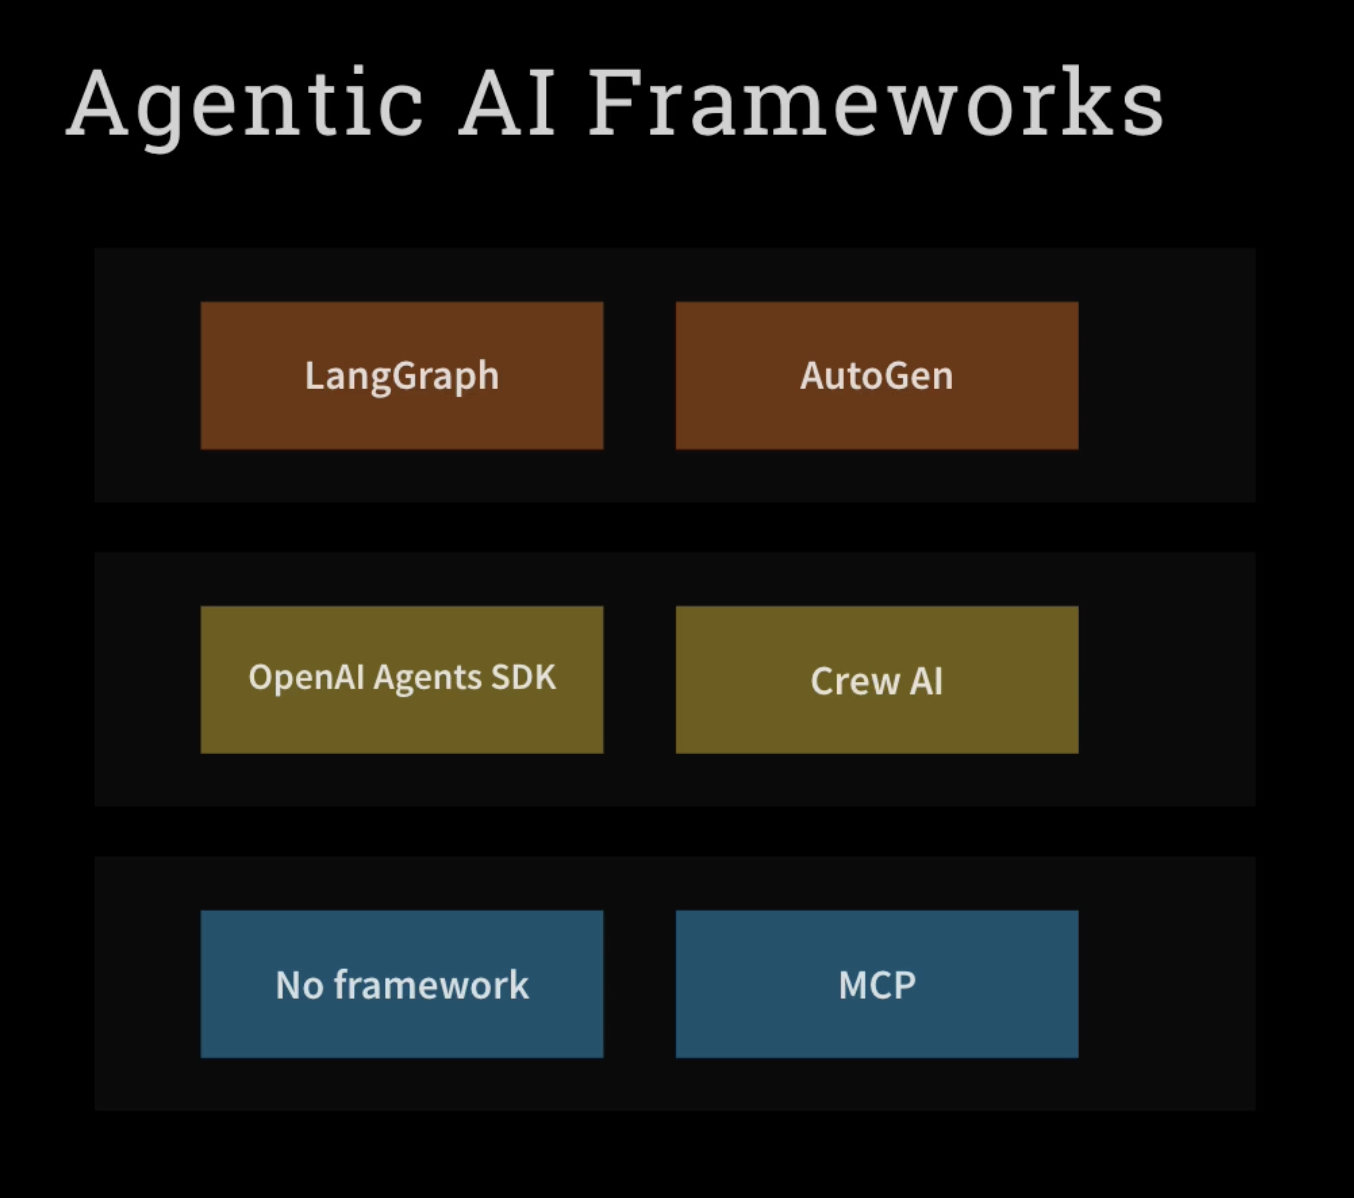

In [18]:
# ── Multi-agent triage system ────────────────────────────────────────────────
SPECIALIST_AGENTS = {
    "MATH":    ("Math Expert",    "You are a mathematics expert. Give precise, step-by-step solutions."),
    "HISTORY": ("History Expert", "You are a history expert. Give accurate, context-rich answers."),
    "SCIENCE": ("Science Expert", "You are a science expert. Give clear, evidence-based explanations."),
    "GENERAL": ("General Assistant", "You are a helpful, knowledgeable assistant."),
}

def run_triage_agent(question: str) -> tuple[str, str]:
    category = llm_call(
        system="Classify this question into exactly one of: MATH, HISTORY, SCIENCE, GENERAL. Reply with ONLY the category word.",
        user=question
    ).strip().upper()
    if category not in SPECIALIST_AGENTS:
        category = "GENERAL"

    role, instructions = SPECIALIST_AGENTS[category]
    answer = llm_call(system=instructions, user=question)
    return f"Routed to: **{role}** (`{category}`)", answer



* Running on local URL:  http://127.0.0.1:7866
* To create a public link, set `share=True` in `launch()`.


In [19]:
question ="When did Napolean Bonapatre born?"
llm_call(
        system="Classify this question into exactly one of: MATH, HISTORY, SCIENCE, GENERAL. Reply with ONLY the category word.",
        user=question
    ).strip().upper()

'HISTORY'

---
# Part 3 — Workflow & Agent Design Patterns

> Source: [Anthropic — Building Effective Agents](https://www.anthropic.com/engineering/building-effective-agents)

Anthropic organises LLM system designs into two categories:

- **Workflows** — the developer defines the control flow; the LLM fills in the content at each fixed step
- **Agents** — the LLM itself decides the control flow dynamically at runtime

```
Workflows (developer controls the flow)    Agents (LLM controls the flow)
────────────────────────────────────────   ──────────────────────────────
1. Prompt Chaining                         6. Autonomous Agent
2. Routing
3. Parallelization
4. Orchestrator-Workers
5. Evaluator-Optimizer
```

Patterns 1–5 are covered first. A detailed **Workflows vs. Agents** comparison appears between Pattern 5 and Pattern 6.

---
## Pattern 1 — Prompt Chaining

**Concept:** Break a task into a fixed sequence of LLM calls where each step feeds the next.

```
Input → [Step 1: Outline] → [Step 2: Draft] → [Step 3: Polish] → Output
```

**When to use:** Task can be decomposed into clear sequential sub-steps; intermediate outputs can be validated.

In [ ]:
# ── Prompt Chaining: Blog Post Pipeline ──────────────────────────────────────
def prompt_chaining_pipeline(topic: str) -> tuple[str, str, str]:

    print(topic)
    outline = llm_call(
        system="You are a technical blog writer. Create concise outlines.",
        user=f"Create a 4-point outline for a blog post titled: '{topic}'"
    )
    print(outline)
    draft_intro = llm_call(
        system="You are a technical blog writer. Write engaging introductions.",
        user=f"Write a 2-paragraph introduction based on this outline:\n{outline}"
    )
    print(draft_intro)
    polished = llm_call(
        system="You are an editor. Make text more engaging, punchy, and professional.",
        user=f"Polish and improve this introduction:\n{draft_intro}"
    )
    return outline, draft_intro, polished



* Running on local URL:  http://127.0.0.1:7867
* To create a public link, set `share=True` in `launch()`.


---
## Pattern 2 — Routing

**Concept:** Classify the input first, then route to the most appropriate specialized handler.

```
             ┌──► [Billing Specialist]
Input ──► [Classifier] ──► [Technical Support]
             └──► [General Service]
```

**When to use:** Inputs fall into distinct categories each needing different instructions or models.

In [ ]:
# ── Routing Pattern: Customer Support ────────────────────────────────────────
SUPPORT_ROUTES = {
    "BILLING": "You are a billing specialist. Help with invoices, payments, refunds, and subscriptions. Be empathetic and solution-focused.",
    "TECHNICAL": "You are a technical support engineer. Help debug issues, configure settings, and explain error messages. Be precise.",
    "GENERAL": "You are a friendly customer service agent. Handle general inquiries and ensure customer satisfaction.",
}

def route_and_respond(message: str) -> tuple[str, str]:
    category = llm_call(
        system="Classify customer messages into exactly one of: BILLING, TECHNICAL, GENERAL. Reply with ONLY the category word.",
        user=message
    ).strip().upper()
    if category not in SUPPORT_ROUTES:
        category = "GENERAL"
    response = llm_call(system=SUPPORT_ROUTES[category], user=message)
    return f"**Routed to:** {category}", response



---
## Pattern 3 — Parallelization

**Concept:** Run multiple LLM calls simultaneously. Two variants:
- **Sectioning** — divide into independent sub-tasks, run in parallel
- **Voting** — run the same task N times, take majority result

```
         ┌──► [Worker 1: Health Benefits] ──┐
Input ───├──► [Worker 2: Value for Money] ──┼──► Aggregated Report
         ├──► [Worker 3: Target Audience] ──┤
         └──► [Worker 4: Key Risks]  ───────┘
```

In [ ]:
# ── Parallelization: Product Analyzer ────────────────────────────────────────
ANALYSIS_ASPECTS = {
    "Health & Wellness Benefits":   "Analyze only the health and wellness benefits of this product in 2-3 sentences.",
    "Value for Money":              "Analyze only the pricing and value proposition of this product in 2-3 sentences.",
    "Target Audience":              "Identify only the ideal target customer for this product in 2-3 sentences.",
    "Key Risks / Downsides":        "Identify the top 2 potential downsides or risks of this product.",
}

def analyze_aspect(aspect: str, prompt: str, product: str) -> tuple[str, str]:
    result = llm_call(
        system="You are a product analyst. Be concise and specific.",
        user=f"{prompt}\n\nProduct description:\n{product}"
    )
    return aspect, result

def parallel_product_analysis(product_desc: str) -> tuple[str, str, str, str, str]:
    start = time.time()
    with concurrent.futures.ThreadPoolExecutor() as executor:
        futures = {
            executor.submit(analyze_aspect, aspect, prompt, product_desc): aspect
            for aspect, prompt in ANALYSIS_ASPECTS.items()
        }
        results = {}
        for f in concurrent.futures.as_completed(futures):
            aspect, result = f.result()
            results[aspect] = result
    elapsed = time.time() - start
    timing  = f"Completed **{len(results)} analyses in parallel** in `{elapsed:.1f}s`"
    return (timing,
            results.get("Health & Wellness Benefits", ""),
            results.get("Value for Money", ""),
            results.get("Target Audience", ""),
            results.get("Key Risks / Downsides", ""))



---
## Pattern 4 — Orchestrator-Workers

**Concept:** A central **orchestrator** LLM dynamically plans the work and delegates to **worker** LLMs. Unlike prompt chaining, the orchestrator decides *at runtime* what to delegate.

```
                    ┌──► [Worker: Research sub-topic 1]
User ──► [Orchestrator] plans ──► [Worker: Research sub-topic 2]
                    └──► [Worker: Research sub-topic 3]
                              ↓
                    [Worker: Critic]  ──► [Worker: Formatter] ──► Final Report
```

In [ ]:
# ── Orchestrator-Workers: Research Report ────────────────────────────────────
def researcher_worker(topic: str) -> tuple[str, str]:
    return topic, llm_call(
        system="You are a research analyst. Provide 3 key facts with data points.",
        user=f"Research and provide 3 key facts about: {topic}"
    )

def critic_worker(content: str) -> str:
    return llm_call(
        system="You are a critical analyst. Identify gaps and limitations.",
        user=f"Identify 2 limitations or counterpoints for:\n{content}"
    )

def formatter_worker(content: str) -> str:
    return llm_call(
        system="You are a technical writer. Format content as a clear executive summary with markdown headers.",
        user=f"Format this as a concise executive summary:\n{content}"
    )

def run_orchestrator(research_topic: str) -> tuple[str, str]:
    # Orchestrator plans sub-topics
    plan_raw = llm_call(
        system="You manage a research pipeline. Output ONLY a JSON array of 3 specific sub-topic strings.",
        user=f"Break into 3 focused sub-topics: {research_topic}"
    )
    try:
        text = plan_raw.strip()
        if "```" in text:
            text = text.split("```")[1].lstrip("json")
        sub_topics = json.loads(text)
    except Exception:
        sub_topics = [research_topic + " overview",
                      research_topic + " challenges",
                      research_topic + " future"]

    plan_display = "**Orchestrator plan:**\n" + "\n".join(f"- {t}" for t in sub_topics)

    # Dispatch workers in parallel
    with concurrent.futures.ThreadPoolExecutor() as executor:
        research_results = dict(executor.map(researcher_worker, sub_topics))

    combined = "\n\n".join(f"**{t}:**\n{r}" for t, r in research_results.items())
    critique  = critic_worker(combined)
    report    = formatter_worker(combined + f"\n\n**Limitations:**\n{critique}")
    return plan_display, report



---
## Pattern 5 — Evaluator-Optimizer

**Concept:** Two LLMs in a loop — a **generator** produces output, an **evaluator** critiques it, the generator improves.

```
                 ┌────────────── feedback ──────────────┐
                 ▼                                      │
Input ──► [Generator] ──► output ──► [Evaluator] ──► score
                                          │
                                   (score >= 8?)
                                          │ YES
                                          ▼
                                       Output
```

**When to use:** Quality matters and you have clear, articulable criteria for "good".

In [ ]:
# ── Evaluator-Optimizer: Code Review Loop ────────────────────────────────────
def code_generator(task: str, requirements: str, feedback: str = "") -> str:
    prompt = f"Task: {task}\n\nRequirements:\n{requirements}"
    if feedback:
        prompt += f"\n\nPrevious reviewer feedback to address:\n{feedback}"
    return llm_call(
        system="You are a Python developer. Write clean, production-quality Python code. Return ONLY the code.",
        user=prompt
    )

def code_evaluator(code: str, requirements: str) -> dict:
    raw = llm_call(
        system=(
            'You are a senior code reviewer. Reply ONLY in this JSON format: '
            '{"score": <1-10>, "passed": <true if score>=8>, "feedback": "<improvements>"}'
        ),
        user=f"Requirements:\n{requirements}\n\nCode:\n{code}"
    )
    try:
        text = raw.strip()
        if "```" in text:
            text = text.split("```")[1].lstrip("json")
        return json.loads(text)
    except Exception:
        return {"score": 5, "passed": False, "feedback": raw}

def run_evaluator_optimizer(task: str, requirements: str, max_iter: int = 3) -> tuple[str, str]:
    feedback   = ""
    trace_lines = []
    final_code  = ""

    for i in range(1, max_iter + 1):
        code  = code_generator(task, requirements, feedback)
        eval_ = code_evaluator(code, requirements)
        score   = eval_.get("score", 0)
        passed  = eval_.get("passed", False)
        feedback = eval_.get("feedback", "")
        final_code = code

        status = "PASSED" if passed else "needs improvement"
        trace_lines.append(f"**Iteration {i}:** Score `{score}/10` — {status}")
        if feedback and not passed:
            trace_lines.append(f"  - Feedback: {feedback[:200]}")

        if passed:
            trace_lines.append(f"\nAccepted after **{i}** iteration(s).")
            break
    else:
        trace_lines.append("\nMax iterations reached — using final version.")

    return "\n".join(trace_lines), final_code



---
## Workflows vs. Agents — What's the Difference?

Before moving to Pattern 6, it's worth pausing on the key distinction Anthropic draws.

### Workflows
Patterns 1–5 are all **workflows** — the *developer* defines the control flow upfront:

| Pattern | Who decides the flow? |
|---|---|
| Prompt Chaining | Developer hardcodes: Step 1 → Step 2 → Step 3 |
| Routing | Developer defines the categories and handlers |
| Parallelization | Developer defines which tasks run in parallel |
| Orchestrator-Workers | Orchestrator LLM plans, but *within a fixed pipeline shape* |
| Evaluator-Optimizer | Developer defines the loop: generate → evaluate → repeat |

The LLM fills in the *content* at each step, but the *structure* is fixed in code.

```
Workflow:  [fixed step 1] → [fixed step 2] → [fixed step 3]
                ↑                 ↑                 ↑
           LLM fills         LLM fills         LLM fills
           the content       the content       the content
```

**Advantages:** Predictable, easy to test, easy to debug, cheaper to run.

---

### Agents
**Agents** let the LLM decide the flow itself — what to do next, which tools to call, when to stop.

```
Agent:   Goal → [LLM decides] → action → observe → [LLM decides] → action → ...
                      ↑                                    ↑
               picks the next step                  adapts based on result
```

**Advantages:** Handles open-ended problems, adapts to unexpected results, no need to anticipate every path.

**Trade-offs:**

| | Workflow | Agent |
|---|---|---|
| **Predictability** | High — same structure every run | Lower — path varies with input |
| **Debuggability** | Easy — fixed steps to inspect | Harder — dynamic flow |
| **Cost** | Lower — known number of LLM calls | Higher — variable, can spiral |
| **Flexibility** | Low — can't handle surprises | High — adapts at runtime |
| **Best for** | Well-defined, repeatable tasks | Open-ended, exploratory tasks |

> **Rule of thumb (Anthropic):** Start with the simplest workflow that works. Only reach for a fully autonomous agent when the task genuinely cannot be structured upfront.

---
## Pattern 6 — Autonomous Agent

**Concept:** The LLM *dynamically* directs its own process — it decides which tools to use, in what order, based on what it observes. No fixed flow.

```
Goal ──► [LLM] ──► pick tool ──► execute ──► observe result
              ▲                                     │
              └──────────── loop ◄──────────────────┘
                                    │ (done?)
                                    ▼
                               Final Answer
```

**When to use:** Open-ended problems where the solution path cannot be defined upfront.

In [ ]:
# ── Autonomous Agent: Sales Data Analysis ────────────────────────────────────
SALES_DATA = [
    {"month": "Jan", "product": "Widget A", "sales": 1200, "region": "North"},
    {"month": "Jan", "product": "Widget B", "sales": 800,  "region": "South"},
    {"month": "Feb", "product": "Widget A", "sales": 1500, "region": "North"},
    {"month": "Feb", "product": "Widget B", "sales": 950,  "region": "South"},
    {"month": "Mar", "product": "Widget A", "sales": 1100, "region": "North"},
    {"month": "Mar", "product": "Widget B", "sales": 1200, "region": "South"},
    {"month": "Apr", "product": "Widget A", "sales": 1800, "region": "North"},
    {"month": "Apr", "product": "Widget B", "sales": 750,  "region": "South"},
]

def get_data_schema() -> str:
    return json.dumps({"columns": list(SALES_DATA[0].keys()), "row_count": len(SALES_DATA), "sample": SALES_DATA[:2]})

def filter_data(column: str, value: str) -> str:
    return json.dumps([r for r in SALES_DATA if str(r.get(column, "")) == str(value)])

def aggregate_sum(column: str, group_by: str) -> str:
    groups: dict = {}
    for r in SALES_DATA:
        k = r.get(group_by, "Unknown")
        groups[k] = groups.get(k, 0) + r.get(column, 0)
    return json.dumps(groups)

def calculate_stats(values: str) -> str:
    nums = json.loads(values)
    if not nums:
        return json.dumps({"error": "empty"})
    return json.dumps({"mean": round(sum(nums)/len(nums), 2), "min": min(nums), "max": max(nums), "total": sum(nums)})

DATA_TOOL_MAP = {"get_data_schema": get_data_schema, "filter_data": filter_data,
                 "aggregate_sum": aggregate_sum, "calculate_stats": calculate_stats}

data_tool_defs = [
    {"type": "function", "function": {"name": "get_data_schema",
        "description": "Get schema and sample rows of the sales dataset",
        "parameters": {"type": "object", "properties": {}, "additionalProperties": False}}},
    {"type": "function", "function": {"name": "filter_data",
        "description": "Filter rows where column equals value",
        "parameters": {"type": "object", "properties": {
            "column": {"type": "string"}, "value": {"type": "string"}},
            "required": ["column", "value"], "additionalProperties": False}}},
    {"type": "function", "function": {"name": "aggregate_sum",
        "description": "Sum a numeric column grouped by another column",
        "parameters": {"type": "object", "properties": {
            "column": {"type": "string"}, "group_by": {"type": "string"}},
            "required": ["column", "group_by"], "additionalProperties": False}}},
    {"type": "function", "function": {"name": "calculate_stats",
        "description": "Compute mean/min/max/total for a JSON list of numbers",
        "parameters": {"type": "object", "properties": {
            "values": {"type": "string"}},
            "required": ["values"], "additionalProperties": False}}},
]

def run_data_agent(goal: str) -> tuple[str, str]:
    messages = [
        {"role": "system", "content": (
            "You are a data analysis agent. Use tools to explore the dataset and answer the question. "
            "Think step by step. When you have the complete answer, provide it."
        )},
        {"role": "user", "content": goal},
    ]
    trace_lines = []

    for step in range(1, 12):
        response = client.chat.completions.create(model=MODEL, messages=messages, tools=data_tool_defs)
        msg    = response.choices[0].message
        finish = response.choices[0].finish_reason

        if finish == "stop":
            trace_lines.append(f"**Done** in {step} step(s).")
            return "\n".join(trace_lines), msg.content

        if finish == "tool_calls":
            messages.append(msg)
            for tc in msg.tool_calls:
                fn   = tc.function.name
                args = json.loads(tc.function.arguments)
                result = DATA_TOOL_MAP[fn](**args)
                short  = result[:100] + "..." if len(result) > 100 else result
                trace_lines.append(f"**Step {step}:** `{fn}({args})` → `{short}`")
                messages.append({"role": "tool", "content": result, "tool_call_id": tc.id})

    return "\n".join(trace_lines), "Max steps reached."



---
# Summary

## Pattern Decision Guide

```
Is the task decomposable into steps?
│
├─ YES, fixed order ─────────────────────── PROMPT CHAINING
│
├─ YES, input type determines path ─────── ROUTING
│
├─ YES, steps are independent ──────────── PARALLELIZATION
│   └─ Need higher confidence? ─────────── use VOTING variant
│
├─ YES, but steps unknown upfront ──────── ORCHESTRATOR-WORKERS
│
├─ Output quality needs iteration ──────── EVALUATOR-OPTIMIZER
│
└─ Open-ended, can't define steps ──────── AUTONOMOUS AGENT
```

## Key Principles (from Anthropic)

1. **Start simple** — use the simplest pattern that solves the problem
2. **Transparency** — make agent reasoning visible for debugging
3. **Human-in-the-loop** — for irreversible or high-stakes actions
4. **Clear stopping conditions** — agents need to know when they are done
5. **Prefer workflows over agents** when structure is known — more predictable, easier to test

## Framework Quick Reference

| Use Case | Recommended |
|---|---|
| Production OpenAI agents | OpenAI Agents SDK |
| RAG + complex pipelines | LangChain / LlamaIndex |
| Multi-agent collaboration | AutoGen / CrewAI |
| Enterprise (.NET/Azure) | Semantic Kernel |
| Claude-native + MCP | Claude Agent SDK |

---
# Part 4 — Model Context Protocol (MCP)

## What is MCP?

**MCP (Model Context Protocol)** is an open standard introduced by Anthropic that defines how AI agents communicate with external tools and data sources in a standardised way.

```
Without MCP (custom per-integration):          With MCP (standard protocol):
─────────────────────────────────────          ─────────────────────────────
Agent ──► custom code ──► Database             Agent
Agent ──► custom code ──► File system            └──► MCP Client
Agent ──► custom code ──► API                         └──► MCP Server ──► Database
Agent ──► custom code ──► Vector DB                                    ──► File system
                                                                        ──► API
                                                                        ──► Vector DB
```

## MCP Primitives

| Primitive | Purpose | Our example |
|---|---|---|
| **Tools** | Callable actions the LLM invokes | DB queries, RAG search |
| **Resources** | Read-only documents the client can fetch | PDF manuals via `doc://` URIs |
| **Prompts** | Reusable prompt templates | (not used in this example) |

## Server Architecture

```
mcp_server.py
 │
 ├── TOOLS (LLM calls these dynamically)
 │    ├── list_equipment(location)          ← DB query
 │    ├── get_upcoming_maintenance(days)    ← DB query
 │    ├── get_equipment_details(name)       ← DB query
 │    ├── maintenance_stats_by_location()   ← DB query
 │    └── search_knowledge_base(query)      ← RAG over vector DB
 │
 └── RESOURCES (client reads these directly)
      ├── doc://PWI_Pump.pdf               ← full pump manual text
      ├── doc://compressed_air_manual.pdf  ← full compressed air manual
      └── doc://heat_pump.pdf              ← full heat pump manual
```

## Example 1 — The MCP Server (`mcp_server.py`)

The server is a **separate Python file** that exposes tools and resources over stdio transport.  
Run it standalone with: `python mcp_server.py`

In [ ]:
# Display the MCP server source so attendees can read it in the notebook
with open("mcp_server.py") as f:
    server_source = f.read()

from IPython.display import display
from IPython.display import Code as IPCode
display(IPCode(server_source, language="python"))

## Example 2 — Discover Tools and Resources from the MCP Server

Connect to the server and list everything it exposes — tools **and** resources.  
This is how any MCP client discovers capabilities at runtime without hardcoding anything.

In [ ]:
import asyncio
import sys
from mcp import ClientSession, StdioServerParameters
from mcp.client.stdio import stdio_client

SERVER_PARAMS = StdioServerParameters(
    command=sys.executable,   # same Python interpreter as the notebook
    args=["mcp_server.py"],
    env=None
)

async def discover_server():
    async with stdio_client(SERVER_PARAMS) as (read, write):
        async with ClientSession(read, write) as session:
            await session.initialize()

            tools     = (await session.list_tools()).tools
            resources = (await session.list_resources()).resources
            return tools, resources

tools_list, resources_list = asyncio.run(discover_server())

print(f"TOOLS ({len(tools_list)}):")
for t in tools_list:
    print(f"  • {t.name}")
    print(f"    {t.description[:100]}...")
    print()

print(f"RESOURCES ({len(resources_list)}):")
for r in resources_list:
    print(f"  • {r.uri}  —  {r.description[:80]}...")

## Example 3 — Reading a Resource Directly

**Resources** are read-only documents exposed by the MCP server via `doc://` URIs.  
Unlike tools (which the LLM calls), resources can be fetched directly by the client — useful for loading full manuals into context.

```
client.read_resource("doc://PWI_Pump.pdf")
     │
     ▼
MCP Server ── _pdf_to_text("knowledge/PWI_Pump.pdf") ──► full text
     │
     ▼
contents[0].text  ← the full document as a string
```

In [ ]:
async def read_manual_resource(uri: str) -> str:
    """Fetch a resource from the MCP server by its doc:// URI."""
    async with stdio_client(SERVER_PARAMS) as (read, write):
        async with ClientSession(read, write) as session:
            await session.initialize()
            result = await session.read_resource(uri)
            return result.contents[0].text

# Read the first ~800 characters of the pump manual
pump_text = asyncio.run(read_manual_resource("doc://PWI_Pump.pdf"))
print(f"Fetched PWI_Pump.pdf — {len(pump_text):,} characters total")
print("\n--- First 800 characters ---")
print(pump_text[:800])

## Example 4 — MCP-Powered Agent with Tools + RAG

Wire the full MCP server into an OpenAI agent loop.  
The agent has access to **all 5 tools** — DB queries and the RAG search over the PDF manuals.

```
User question
     │
     ▼
[OpenAI LLM] ──── tool_call ────► [MCP Client] ──► [MCP Server subprocess]
     ▲                                                      │  • list_equipment
     └──────────── tool_result ◄───────────────────────────┘  • get_upcoming_maintenance
                                                               • get_equipment_details
                                                               • maintenance_stats_by_location
                                                               • search_knowledge_base (RAG)
```

In [ ]:
def mcp_tool_schema_to_openai(mcp_tool) -> dict:
    """Convert an MCP tool definition into OpenAI function-calling format."""
    schema = mcp_tool.inputSchema if mcp_tool.inputSchema else {"type": "object", "properties": {}}
    schema.setdefault("additionalProperties", False)
    return {
        "type": "function",
        "function": {
            "name": mcp_tool.name,
            "description": mcp_tool.description or "",
            "parameters": schema,
        }
    }

async def run_mcp_agent(user_question: str) -> tuple[str, str]:
    """
    Full agent loop that talks to the MCP server for every tool call.
    Returns (trace_markdown, final_answer).
    """
    async with stdio_client(SERVER_PARAMS) as (read, write):
        async with ClientSession(read, write) as session:
            await session.initialize()

            # ── 1. Discover tools from MCP server ────────────────────────────
            mcp_tools    = (await session.list_tools()).tools
            openai_tools = [mcp_tool_schema_to_openai(t) for t in mcp_tools]

            # ── 2. Build initial messages ─────────────────────────────────────
            messages = [
                {"role": "system", "content": (
                    "You are a maintenance assistant for a manufacturing plant. "
                    "Use the available tools to answer questions about equipment and maintenance schedules. "
                    "For questions about procedures, installation, troubleshooting, or technical specifications, "
                    "use the search_knowledge_base tool to find relevant information from the technical manuals. "
                    "Be concise and accurate."
                )},
                {"role": "user", "content": user_question},
            ]

            trace_lines = []

            # ── 3. Agent loop ─────────────────────────────────────────────────
            for step in range(1, 10):
                response = client.chat.completions.create(
                    model=MODEL, messages=messages, tools=openai_tools
                )
                msg    = response.choices[0].message
                finish = response.choices[0].finish_reason

                if finish == "stop":
                    trace_lines.append(f"**Done** in {step} step(s).")
                    return "\n".join(trace_lines), msg.content

                if finish == "tool_calls":
                    messages.append(msg)
                    for tc in msg.tool_calls:
                        fn_name = tc.function.name
                        fn_args = json.loads(tc.function.arguments)

                        # ── Call the MCP server ───────────────────────────────
                        mcp_result  = await session.call_tool(fn_name, fn_args)
                        result_text = mcp_result.content[0].text if mcp_result.content else "{}"

                        short = result_text[:120] + "..." if len(result_text) > 120 else result_text
                        trace_lines.append(f"**Step {step}:** `{fn_name}({fn_args})` → `{short}`")

                        messages.append({
                            "role": "tool",
                            "content": result_text,
                            "tool_call_id": tc.id
                        })

            return "\n".join(trace_lines), "Max steps reached."


def run_mcp_agent_sync(question: str) -> tuple[str, str]:
    """Sync wrapper so Gradio can call the async agent."""
    return asyncio.run(run_mcp_agent(question))


